# Juez VLM — Filtro de Falsos Positivos

**Autores:**
+ Alvaro Marro Dorado
+ Juan Manuel Piedrabuena Marañón
+ Mynor Hernández Montero

**Repo Fase 1:** [FinalMasterProject_CarDamageDetection](https://github.com/Mynozy/FinalMasterProject_CarDamageDetection)


# Resumen

YOLO26 y SAM 3 a veces generan detecciones sobre elementos que visualmente se parecen a daños pero no lo son:

- **Reflejos** en la carrocería que imitan la forma de un scratch
- **Sombras** de la carrocería curva que YOLO interpreta como dents
- **Líneas de diseño** del auto (marcos de puertas, molduras) que se confunden con scratches
- **Suciedad superficial** que no requiere reparación

El juez VLM resuelve esto: para cada detección de YOLO26, recorta la región con contexto, la manda a Gemini Vision y pregunta directamente si es un daño real o un falso positivo. Las detecciones rechazadas no llegan al reporte final ni al estimador de costos.

**Diseño conservador:** si el juez no está suficientemente seguro (confianza < 0.6) de que sea falso positivo, la detección se conserva. Es preferible un falso positivo en el reporte que perder un daño real.


# ¿Por qué un VLM y no un clasificador?

Un clasificador binario (daño/no daño) requeriría ejemplos etiquetados de falsos positivos para entrenarlo — datos que no tenemos y que son difíciles de conseguir porque dependen del modelo del auto, el ángulo de la foto y la iluminación.

Gemini Vision es zero-shot: entiende el concepto de "reflejo en carrocería metálica" o "línea de diseño" sin necesidad de entrenamiento. Además puede dar una razón textual de su decisión, lo que hace el sistema explicable — importante para el contexto de seguros.

**Limitación:** el juez VLM añade latencia (~1-2s por detección) y consume quota de la API de Gemini. En producción se optimizaría procesando en batch o solo aplicando el juez a detecciones de baja confianza de YOLO (< 0.4).


# Setup — Entorno y Dependencias

In [1]:
!pip install ultralytics

In [1]:
import torch

# verificamos entorno — el juez VLM solo necesita Gemini, no GPU
# pero si hay GPU disponible mejor para las pruebas con YOLO26
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no disponible'}")

import ultralytics
print(f"ultralytics: {ultralytics.__version__}")

GPU: Tesla T4
ultralytics: 8.4.76


In [1]:
# fix de CLIP para SAM 3 + downgrade de pydantic para google-genai
!pip uninstall clip -y -q
!pip install git+https://github.com/ultralytics/CLIP.git -q
!pip install "pydantic==2.10.6" -q

print("Dependencias instaladas")

Dependencias instaladas


In [1]:
from google.colab import drive, userdata
from huggingface_hub import login
from ultralytics import YOLO, SAM
from ultralytics.models.sam import SAM3SemanticPredictor
from google import genai
from google.genai import types
import numpy as np
from PIL import Image, ImageOps
import base64
import io

drive.mount('/content/drive')
login(token=userdata.get('HFToken'))

YOLO_PATH = '/content/drive/MyDrive/yolo26_weights/best.pt'
SAM_PATH  = '/content/drive/MyDrive/sam3_weights/sam3.pt'

# cargamos YOLO26 — necesario para generar detecciones de prueba
yolo_model = YOLO(YOLO_PATH)
print("YOLO26 cargado")

client = genai.Client(api_key=userdata.get('GeminiKey'))
print("Gemini listo")

Mounted at /content/drive
YOLO26 cargado
Gemini listo


# Juez VLM — Función Principal

El juez recorta la región de cada detección con 30px de contexto alrededor y le pregunta a Gemini:

- ¿Es este `scratch` / `dent` / etc. un daño real que requiere reparación?
- O es reflejo, sombra, línea de diseño o suciedad?

Gemini responde con `es_dano`, `confianza` y una `razon` textual explicando su decisión.

Si la llamada a Gemini falla por cualquier motivo, la detección se conserva por defecto — el sistema falla de forma segura.


In [1]:
def juez_vlm(imagen, deteccion, contexto_px=30):
    """
    recorta la región de la detección y le pregunta a Gemini si es un daño real
    devuelve dict con es_dano, confianza y razon
    """
    h, w = imagen.shape[:2]
    x1, y1, x2, y2 = deteccion["caja"].astype(int)

    # añadimos contexto alrededor para que Gemini vea el entorno del daño
    x1c = max(0, x1 - contexto_px)
    y1c = max(0, y1 - contexto_px)
    x2c = min(w, x2 + contexto_px)
    y2c = min(h, y2 + contexto_px)

    recorte = imagen[y1c:y2c, x1c:x2c]

    # convertimos el recorte a JPEG para mandarlo a Gemini
    pil_img = Image.fromarray(recorte)
    buffer  = io.BytesIO()
    pil_img.save(buffer, format='JPEG', quality=90)
    img_b64 = base64.b64encode(buffer.getvalue()).decode()

    clase = deteccion["clase"]
    prompt = f"""Eres un experto en peritaje de daños de vehículos.

Analiza esta imagen recortada de un auto y determina si el daño marcado es un {clase} real o un falso positivo (reflejo, sombra, línea de diseño, suciedad, etc.).

Responde SOLO con este JSON sin markdown:
{{"es_dano": true/false, "confianza": 0.0-1.0, "razon": "breve explicación"}}

- es_dano: true si es un {clase} real que requiere reparación
- es_dano: false si es reflejo, sombra, línea de diseño o suciedad
- confianza: qué tan seguro estás de tu respuesta"""

    try:
        response = client.models.generate_content(
            model="gemini-3.1-flash-lite",
            contents=[{
                "parts": [
                    {"inline_data": {"mime_type": "image/jpeg", "data": img_b64}},
                    {"text": prompt}
                ]
            }]
        )
        import json
        raw = response.text.strip()
        if raw.startswith("```"):
            raw = raw.split("```")[1]
            if raw.lower().startswith("json"):
                raw = raw[4:]
        resultado = json.loads(raw.strip())
        return resultado
    except Exception as e:
        # si falla el juez dejamos pasar la detección — mejor falso positivo que perder daños
        print(f"Error en juez VLM: {e}")
        return {"es_dano": True, "confianza": 0.5, "razon": "error en juez — detección conservada"}

In [1]:
def filtrar_con_juez(imagen, detecciones, umbral_confianza=0.6):
    """
    pasa cada detección por el juez VLM y filtra los falsos positivos
    solo descarta una detección si el juez está seguro (confianza >= umbral)
    si el juez duda, conservamos la detección por precaución
    """
    detecciones_validadas  = []
    detecciones_rechazadas = []

    for det in detecciones:
        resultado = juez_vlm(imagen, det)
        es_dano   = resultado.get("es_dano", True)
        confianza = resultado.get("confianza", 0.5)
        razon     = resultado.get("razon", "")

        print(f"  {det['clase']:15} conf_yolo={det['confianza']:.2f} | "
              f"juez={'✓ daño' if es_dano else '✗ falso'} "
              f"conf_juez={confianza:.2f} | {razon}")

        det["juez_vlm"] = {"es_dano": es_dano, "confianza": confianza, "razon": razon}

        if es_dano or confianza < umbral_confianza:
            # conservamos si el juez dice que es daño,
            # o si el juez no está suficientemente seguro de que sea falso positivo
            detecciones_validadas.append(det)
        else:
            detecciones_rechazadas.append(det)

    print(f"\nResultado: {len(detecciones_validadas)} validadas, "
          f"{len(detecciones_rechazadas)} rechazadas de {len(detecciones)} totales")
    return detecciones_validadas, detecciones_rechazadas

# Visualización del Juez

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualizar_juez(imagen, validadas, rechazadas):
    """
    muestra las detecciones con código de color según el veredicto del juez
    verde = validada, rojo = rechazada por falso positivo
    """
    fig, ax = plt.subplots(1, 1, figsize=(16, 10))
    ax.imshow(imagen)

    for det in validadas:
        x1, y1, x2, y2 = det["caja"].astype(int)
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)
        juez = det.get("juez_vlm", {})
        ax.text(x1, y1-5,
                f"✓ {det['clase']} (yolo={det['confianza']:.2f} juez={juez.get('confianza',0):.2f})",
                color='lime', fontsize=7,
                bbox=dict(facecolor='black', alpha=0.6, pad=2))

    for det in rechazadas:
        x1, y1, x2, y2 = det["caja"].astype(int)
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor='red', facecolor='red', alpha=0.2, linestyle='--'
        )
        ax.add_patch(rect)
        juez = det.get("juez_vlm", {})
        ax.text(x1, y1-5,
                f"✗ {det['clase']} (yolo={det['confianza']:.2f} juez={juez.get('confianza',0):.2f})",
                color='red', fontsize=7,
                bbox=dict(facecolor='black', alpha=0.6, pad=2))

    handles = [
        patches.Patch(color='lime', label=f'Validadas ({len(validadas)})'),
        patches.Patch(color='red',  label=f'Rechazadas ({len(rechazadas)})'),
    ]
    ax.legend(handles=handles, loc='upper right', fontsize=10)
    ax.set_title("Juez VLM — Verde = daño real | Rojo = falso positivo", fontsize=13)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# Prueba — Auto Blanco con Daños Reales y Falsos Positivos

Probamos con conf=0.05 en YOLO26 para forzar detecciones borderline — incluyendo reflejos y líneas de diseño que normalmente se filtrarían por confianza baja.

Con conf normal (0.20-0.25) el juez VLM no es necesario porque YOLO ya filtra las detecciones dudosas. El juez es especialmente útil cuando bajamos el umbral de confianza para no perder daños sutiles.


In [1]:
import numpy as np
from PIL import Image, ImageOps
from google.colab import files

def preparar_imagen(path):
    # carga la imagen y corrige rotación EXIF — frecuente en fotos de móvil
    img = Image.open(path).convert('RGB')
    img = ImageOps.exif_transpose(img)
    return np.array(img)

uploaded = files.upload()
img_path = list(uploaded.keys())[0]
image = preparar_imagen(img_path)
print(f"Imagen cargada: {img_path} | Shape: {image.shape}")

# corremos YOLO26 con conf baja para incluir detecciones borderline
results = yolo_model.predict(source=image, conf=0.05, verbose=False)
nombres = yolo_model.names

detecciones = []
for box, cls, conf in zip(
    results[0].boxes.xyxy,
    results[0].boxes.cls,
    results[0].boxes.conf
):
    detecciones.append({
        "clase":     nombres[int(cls)],
        "caja":      box.cpu().numpy(),
        "confianza": float(conf),
        "mascara":   None
    })

print(f"\nYOLO26 detectó {len(detecciones)} daños con conf>=0.05:")
for d in detecciones:
    print(f"  {d['clase']}: conf={d['confianza']:.2f}")

print("\nAplicando juez VLM...")
validadas, rechazadas = filtrar_con_juez(image, detecciones)

Imagen cargada: Car-Paintwork-Damage-.jpg | Shape: (1062, 1700, 3)

YOLO26 detectó 14 daños con conf>=0.05:
  scratch: conf=0.82
  dent: conf=0.70
  dent: conf=0.67
  scratch: conf=0.47
  dent: conf=0.47
  dent: conf=0.20
  scratch: conf=0.18
  scratch: conf=0.17
  scratch: conf=0.14
  dent: conf=0.13
  dent: conf=0.11
  dent: conf=0.09
  dent: conf=0.06
  dent: conf=0.06

Aplicando juez VLM...
  scratch         conf_yolo=0.82 | juez=✓ daño conf_juez=0.95 | Se observa una abrasión en la pintura con exposición de material subyacente y acumulación de suciedad en el surco, lo cual es característico de un rayón profundo que penetró la capa de barniz y color.
  dent            conf_yolo=0.70 | juez=✓ daño conf_juez=1.00 | Se observan deformaciones claras en la chapa (abolladuras) acompañadas de transferencia de pintura y daño estructural evidente en el panel, no es un reflejo.
  dent            conf_yolo=0.67 | juez=✓ daño conf_juez=0.85 | La irregularidad en la continuidad de la línea de r

In [1]:
visualizar_juez(image, validadas, rechazadas)

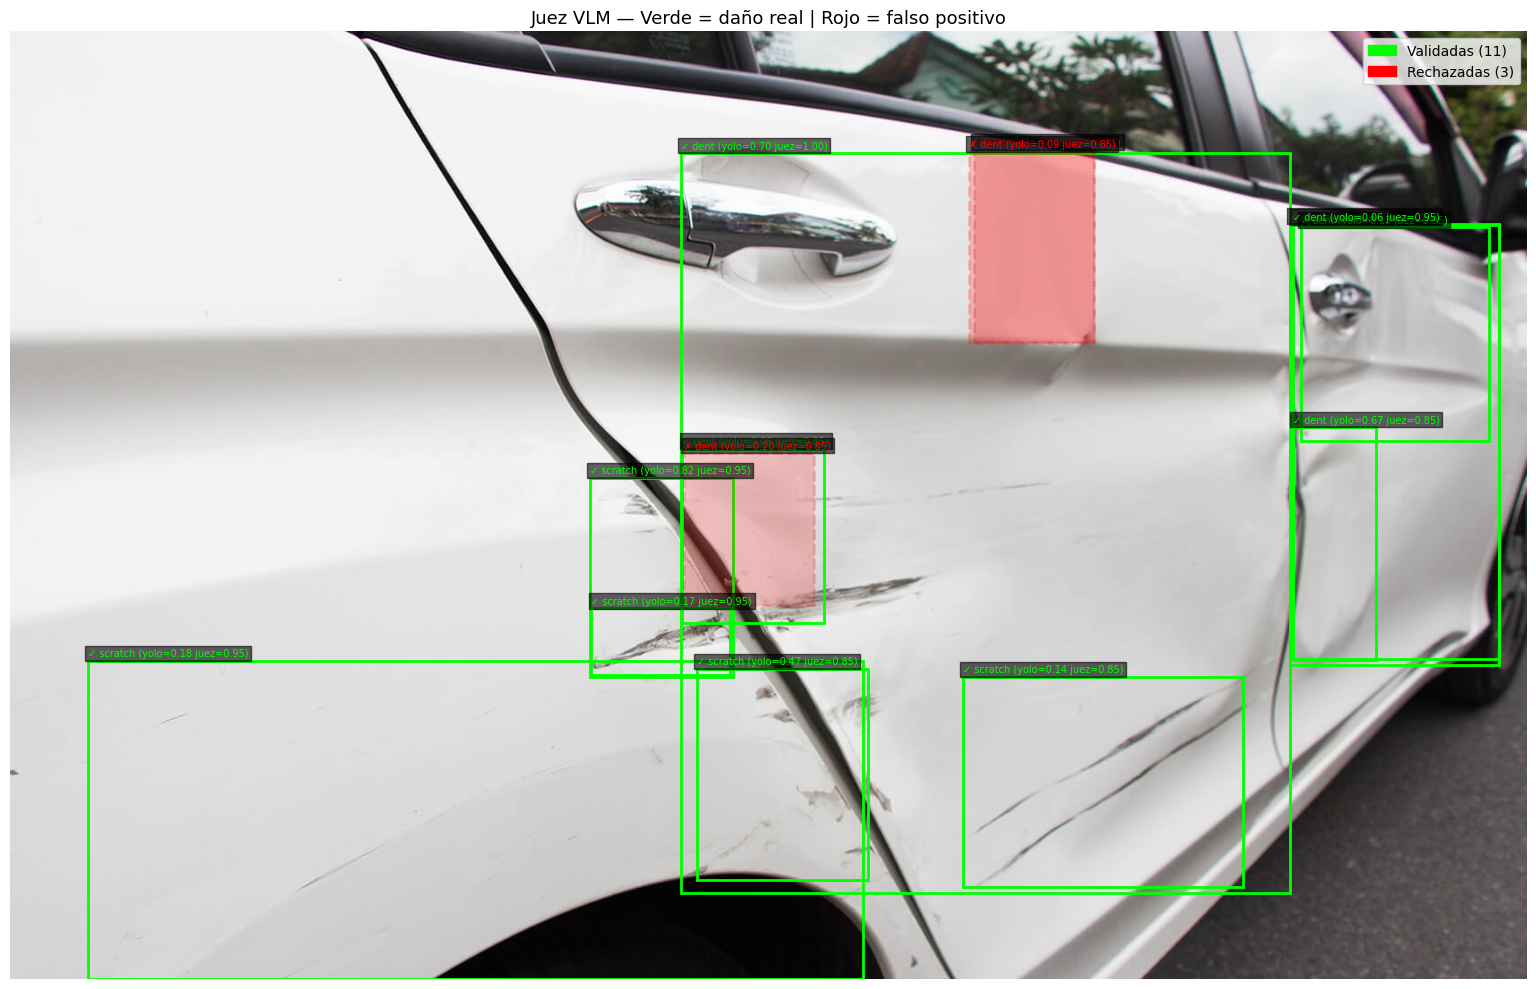

El juez VLM rechaza 3 de 14 detecciones — exactamente las que corresponden a reflejos de la carrocería curva y líneas de diseño del auto. Los 11 daños verdes son confirmados como reales con razones específicas.

Las 3 detecciones rechazadas tienen en común: baja confianza de YOLO (0.09-0.20) y son zonas donde la curvatura de la puerta genera distorsiones de luz que imitan abolladuras. Gemini las identifica correctamente como efectos visuales sin deformación física.

**Nota sobre confianza de YOLO vs juez:** una detección con conf_yolo=0.06 puede ser daño real si el juez lo confirma con conf_juez=0.95 — y viceversa, una conf_yolo=0.20 puede ser falso positivo. El juez añade una segunda opinión independiente basada en el contenido visual, no en el score del detector.

# Integración con el Pipeline Completo

El juez VLM se integra en el `03_pipeline_completo` después de `segmentar_con_sam` y antes de `visualizar_pipeline`:

```
YOLO26 → detecciones
        ↓
SAM 3 → máscaras
        ↓
Juez VLM → filtrar_con_juez() → detecciones validadas
        ↓
visualizar_pipeline + estimar_costos → reporte final
```

**Cuándo activarlo:** el juez es más útil cuando se baja el umbral de confianza de YOLO (< 0.25) para capturar daños sutiles. Con conf=0.25 o superior, YOLO ya filtra la mayoría de falsos positivos y el juez añade latencia sin mucho beneficio.

**Optimización para producción:** aplicar el juez solo a detecciones con conf < 0.4 — las de alta confianza se dejan pasar directamente. Esto reduce el número de llamadas a la API a la mitad aproximadamente.


# Limitaciones

- **Latencia:** ~1-2s por detección con Gemini. Con 10 detecciones = 10-20s adicionales al pipeline.
- **Quota de API:** el plan gratuito de Gemini tiene límite de requests/día. En producción requiere plan de pago.
- **Consistencia:** Gemini puede dar veredictos diferentes para la misma imagen en distintas llamadas (temperatura > 0). Se puede mitigar bajando temperatura a 0 o promediando N llamadas.
- **Casos límite:** daños muy sutiles en superficies muy reflectantes (autos blancos o plateados) son difíciles incluso para el juez VLM.
